In [1]:
import math
import os
import scipy
from scipy.optimize import lsq_linear
import numpy as np
from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, halfnorm
import random
from scipy.io import loadmat
import random
import pickle
import sys
from sklearn.linear_model import RidgeCV
sys.path.append(r"c:\Users\katie\OneDrive\Documents\GitHub\trial")
import PCA_Regress as pcar
from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec

In [ ]:
# J neural interpPSTH
base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_neu.pkl', "rb") as input_file:
    J_pickle = pickle.load(input_file)
del input_file

# N neural interpPSTH
file_path = os.path.join(base_path, 'N_neu.pkl')
with open(file_path, "rb") as input_file:
    N_pickle = pickle.load(input_file)
del input_file

# J neural mean firing rates
file_path = os.path.join(base_path, 'J_neu_FR.pkl')
with open(file_path, "rb") as input_file:
    J_pickle_FR = pickle.load(input_file)
del input_file

# N neural mean firing rates
file_path = os.path.join(base_path, 'N_neu_FR.pkl')
with open(file_path, "rb") as input_file:
    N_pickle_FR = pickle.load(input_file)
del input_file

# J muscle interpPSTH
base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_mus.pkl', "rb") as input_file:
    J_pickle_m = pickle.load(input_file)
del input_file

# N muscle interpPSTH
ile_path = os.path.join(base_path, 'N_mus.pkl')
with open(ile_path, "rb") as input_file:
    N_pickle_m = pickle.load(input_file)
del input_file

# J muscle mean firing rates
file_path = os.path.join(base_path, 'muscle_J_FR.pkl')
with open(file_path, "rb") as input_file:
    J_pickle_m_FR = pickle.load(input_file)
del input_file

# N msucle mean firing rates
ile_path = os.path.join(base_path, 'muscle_N_FR.pkl')
with open(ile_path, "rb") as input_file:
    N_pickle_m_FR = pickle.load(input_file)
del input_file

# base_path = "/Users/kb6113/Desktop/Thesis"
# with open(base_path+'/J_neu.pkl', "rb") as input_file:
#     J_pickle = pickle.load(input_file)
# del input_file

# with open(base_path+'/J_mus.pkl', "rb") as input_file:
#     J_pickle_m = pickle.load(input_file)
# del input_file

# INTER P PSTH
J_all_tensor = J_pickle['J_all']['interpPSTH']
J_M1_tensor = J_pickle['J_M1']['interpPSTH']
J_PMd_tensor = J_pickle['J_PMd']['interpPSTH']
J_idx = np.r_[0:18, 36:45]
J_ntm_tensor = J_all_tensor[J_idx, :, :]
J_mus_tensor = J_pickle_m['interpPSTH']

N_all_tensor = N_pickle['N_all']['interpPSTH']
N_M1_tensor = N_pickle['N_M1']['interpPSTH']
N_PMd_tensor = N_pickle['N_PMd']['interpPSTH']
N_mus_tensor = N_pickle_m['interpPSTH']

# MEAN FR
J_all_FR = J_pickle_FR['J_all_FR']['mean_FR']
J_M1_FR = J_pickle_FR['J_M1_FR']['mean_FR']
J_PMd_FR = J_pickle_FR['J_PMd_FR']['mean_FR']
J_idx = np.r_[0:18, 36:45]
J_ntm_FR = J_all_FR[J_idx, :, :]
J_mus_FR = J_pickle_m_FR['mean_FR']

N_all_FR = N_pickle_FR['N_all_FR']['mean_FR']
N_M1_FR = N_pickle_FR['N_M1_FR']['mean_FR']
N_PMd_FR = N_pickle_FR['N_PMd_FR']['mean_FR']
N_mus_FR = N_pickle_m_FR['mean_FR']


<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
C:\Users\katie\AppData\Local\Temp\ipykernel_12232\3800015342.py:2: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_neu.pkl', "rb") as input_file:
C:\Users\katie\AppData\Local\Temp\ipykernel_12232\3800015342.py:12: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_mus.pkl', "rb") as input_file:


[18 10  2  7  1 16 15 21 12  0 19 17 23  4  3  9 26 20 22 25  6 13]
>>> best_lam returning: 11.937766417144381
frac null:  0.7685132105782695
frac potent:  0.23148678942173265


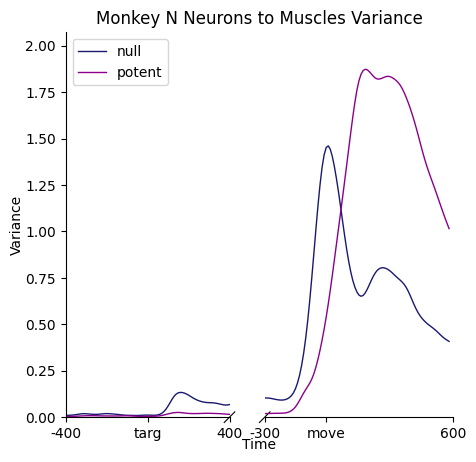

In [3]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor)

[13 22  6 16  4  0 26 14 25 24 23  3  5  7 18  2 15 10 20 12  8 19]
>>> best_lam returning: 34.55107294592218
frac null:  0.600220312405635
frac potent:  0.39977968759436694


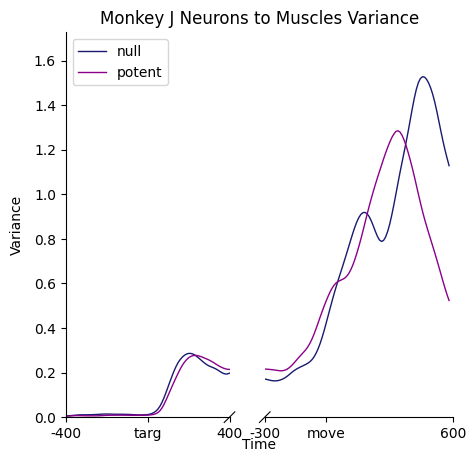

In [4]:
pcar.sup_tuning(J_ntm_tensor, J_mus_tensor)

# best lam = 100

[ 9 14  0 16 11  3 24 21 23  8 15 18 25 19 10 13 17 20  6  1  2 22]
>>> best_lam returning: 34.55107294592218
frac null:  0.5811690733962267
frac potent:  0.41883092660377463


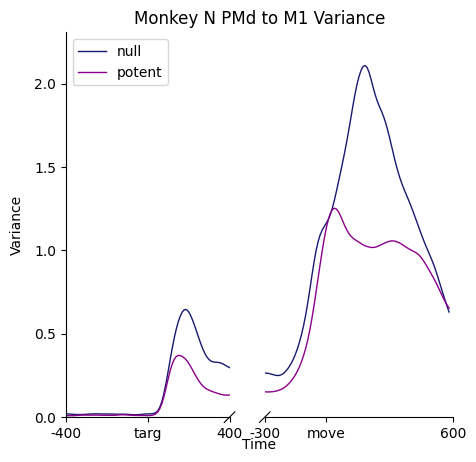

In [15]:
pcar.sup_tuning(N_PMd_tensor, N_M1_tensor, dims = 14) 

# best lam = 58.780160722749116

[ 2 18  8 21  4 19 12  5  0  9 20  6 14 13 10 25 15 24  7 23  1 16]
>>> best_lam returning: 20.30917620904739
[16  7 10 12  6  8 21 17 11  0 18 20 13 22 23 25  5  1 24 19  9]
>>> best_lam returning: 34.55107294592218
[23 13 14  1  4 21  5  8  2 20 16 15 18 17 10  0 12  6  7 19]
>>> best_lam returning: 34.55107294592218
[ 4 15  0 14  6 11 17  2  5  9 12  8  1 10  3  7 13]
>>> best_lam returning: 20.30917620904739
frac null:  0.5834198131313665
frac potent:  0.4165801868686333


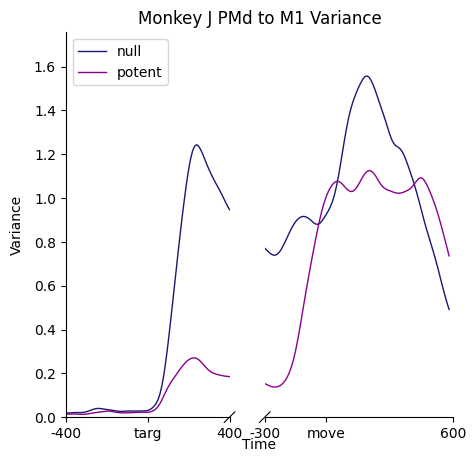

In [6]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[ 8 23  2  7 15 21 13 25 11 10  5 12  3  0  6 24 14 20 17 19 22  9]
>>> best_lam returning: 20.30917620904739
[16 20  0  1  2 21  9 11 12  3  5 15  7 18  6 14 17 22 10 24  8]
>>> best_lam returning: 20.30917620904739
[ 0 21 16 23 11  1  2  9 13  4 22 10 20 19  7  6 14 17  3 12]
>>> best_lam returning: 11.937766417144381
[ 8  3 18 11 16  5  7  4 12 14 19  2  1  9  0 13 10]
>>> best_lam returning: 20.30917620904739
frac null:  0.5907207048901328
frac potent:  0.40927929510986727


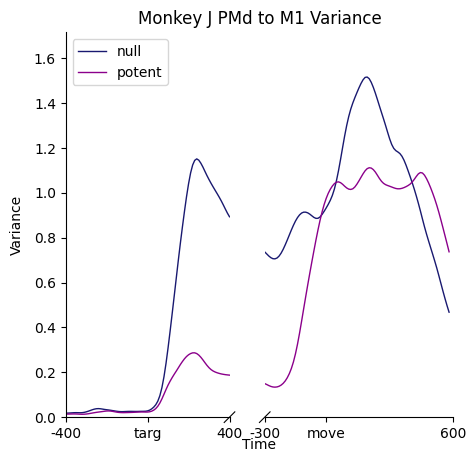

In [7]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[17 26  0 20 25  9 24  5 16  6  2 11 23  3 22 13 10 19 14  7 18  8]
>>> best_lam returning: 34.55107294592218
frac null:  0.7631372763460603
frac potent:  0.23686272365393948


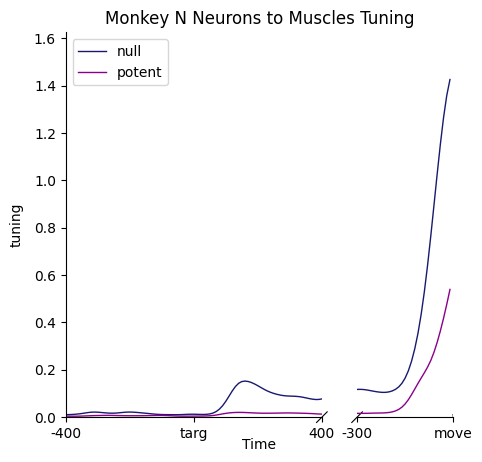

In [8]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor, fig_4D = True)

In [9]:
def fig4_d (tensor_N, tensor_M, dims):

    
    # retrieving dataset specifications 
    J, PMd = pcar.ident(tensor_N)

    # getting weights matrix for potent and null space 
    cond, _, fin_time = tensor_N.shape
    regress_N, _, _ = pcar.time_shift(tensor_N, tensor_M, fig4 = True)
    N_tilde, _, _ = pcar.run_PCA(regress_N, dims)
    W_potent, W_null = pcar.tuning_setup(tensor_N, tensor_M, dims, time = True)
    
    # projecting the neural activity of 400ms before and after target and 300ms before and 800ms after move starts onto the potent and null space of the weights matrix
    N_potent = N_tilde @ W_potent
    N_null = N_tilde @ W_null

    # reshaping into a tensor 
    pot_tensor = pcar.shape_tensor(N_potent, cond)
    null_tensor = pcar.shape_tensor(N_null, cond)
    _, _, time = pot_tensor.shape

    # initializing array for holding the variance 
    V_pot = np.zeros(time)
    V_null = np.zeros(time)
    _, _, time = null_tensor.shape

    ratio = np.zeros(time)

    for t in range(time):

        Xn = null_tensor[:,:,t]
        Xp = pot_tensor[:,:,t]

        # subtract condition mean
        Xn -= Xn.mean(axis=0, keepdims=True)
        Xp -= Xp.mean(axis=0, keepdims=True)

        V_null = np.sum(Xn**2)
        V_pot  = np.sum(Xp**2)

        ratio[t] = (1/gamma) * (V_null / V_pot)